# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [1]:
# # Instalação base do projeto + PyTorch com CUDA (Windows / pip)

# %pip install -q --upgrade pip

# # Dependências gerais
# %pip install -q \
#     numpy \
#     pandas \
#     matplotlib \
#     pillow \
#     tqdm \
#     scipy \
#     scikit-learn \
#     jupyter \
#     ipykernel \
#     datasets \
#     accelerate \
#     diffusers \
#     transformers \
#     clean-fid \
#     torchmetrics

# # PyTorch com CUDA (instalar em separado)
# %pip uninstall -y torch torchvision torchaudio
# %pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [2]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

In [3]:
import torch

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))
else:
    print("GPU não disponível para o PyTorch neste ambiente.")

torch version: 2.6.0+cu124
cuda available: True
cuda device count: 1
gpu name: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
KAGGLE_ROOT = PROJECT_ROOT / "ArtBench-10"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("KAGGLE_ROOT  =", KAGGLE_ROOT)
print("SCRIPTS_DIR  =", SCRIPTS_DIR)

PROJECT_ROOT = c:\git\GAI-Project1
KAGGLE_ROOT  = c:\git\GAI-Project1\ArtBench-10
SCRIPTS_DIR  = c:\git\GAI-Project1\scripts


In [5]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='c:\git\GAI-Project1\ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [6]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [7]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [8]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


## Visualize a sample grid

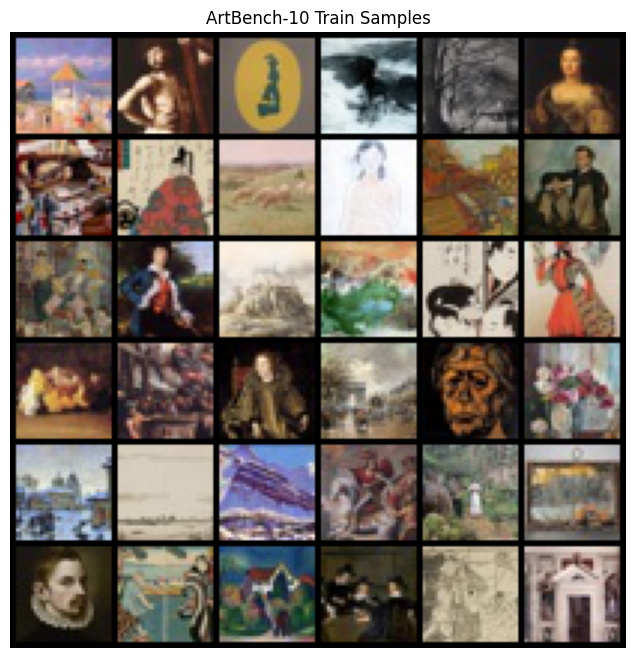

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [9]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [10]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data\train_subset\images
Metadata CSV: exported_data\train_subset\metadata.csv


# Common Utilities

In [11]:
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def denorm(x):
    return x.clamp(-1, 1).add(1).div(2)


@torch.no_grad()
def show_image_grid(images, title="Images", nrow=8, figsize=(8, 8), normalize=False):
    images = images.detach().cpu()

    if normalize:
        images = denorm(images)

    grid = make_grid(images, nrow=nrow, padding=2)
    grid = grid.permute(1, 2, 0)

    plt.figure(figsize=figsize)
    plt.imshow(grid)
    plt.title(title)
    plt.axis("off")
    plt.show()


def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(8, 4))
    for key, values in history.items():
        plt.plot(values, label=key)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def save_checkpoint(model, optimizer, epoch, path, history=None, extra=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "history": history,
        "extra": extra,
    }
    torch.save(checkpoint, path)
    print(f"Checkpoint saved to: {path}")


def load_checkpoint(model, optimizer, path, map_location="cpu"):
    checkpoint = torch.load(path, map_location=map_location)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and checkpoint["optimizer_state_dict"] is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    print(f"Checkpoint loaded from: {path}")
    return checkpoint

# ConvVAE

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: [B, 3, 32, 32] -> [B, 256, 4, 4]
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # -> 16x16
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # -> 8x8
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # -> 4x4
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # -> 4x4
            nn.ReLU(inplace=True),
        )

        self.flatten_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Decoder: [B, latent_dim] -> [B, 3, 32, 32]
        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1), # -> 4x4
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> 8x8
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # -> 16x16
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # -> 32x32
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), 256, 4, 4)
        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / x.size(0)

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

### VAE Utilities

In [13]:
@torch.no_grad()
def show_vae_reconstructions(model, dataloader, device, num_images=16):
    """
    Show original images and their reconstructions side by side.
    """
    model.eval()

    batch = next(iter(dataloader))
    x, y, real_idx = batch
    x = x.to(device)

    x_hat, mu, logvar = model(x)

    x = x[:num_images].cpu()
    x_hat = x_hat[:num_images].cpu()

    print("Original images")
    show_image_grid(x, title="Original Images", nrow=4, figsize=(8, 8), normalize=False)

    print("Reconstructed images")
    show_image_grid(x_hat, title="Reconstructed Images", nrow=4, figsize=(8, 8), normalize=False)


@torch.no_grad()
def sample_vae(model, device, num_samples=16):
    """
    Sample new images from the VAE latent space.
    """
    model.eval()

    z = torch.randn(num_samples, model.latent_dim, device=device)
    samples = model.decode(z).cpu()

    show_image_grid(samples, title="VAE Samples", nrow=4, figsize=(8, 8), normalize=False)
    return samples


@torch.no_grad()
def interpolate_vae(model, dataloader, device, num_steps=8):
    """
    Interpolate between two images in latent space and decode the intermediate points.
    """
    model.eval()

    batch = next(iter(dataloader))
    x, y, real_idx = batch
    x = x.to(device)

    x1 = x[0:1]
    x2 = x[1:2]

    mu1, logvar1 = model.encode(x1)
    mu2, logvar2 = model.encode(x2)

    z1 = model.reparameterize(mu1, logvar1)
    z2 = model.reparameterize(mu2, logvar2)

    alphas = torch.linspace(0.0, 1.0, steps=num_steps, device=device)

    z_interp = []
    for alpha in alphas:
        z = (1 - alpha) * z1 + alpha * z2
        z_interp.append(z)

    z_interp = torch.cat(z_interp, dim=0)
    x_interp = model.decode(z_interp).cpu()

    show_image_grid(x_interp, title="VAE Latent Interpolation", nrow=num_steps, figsize=(2 * num_steps, 2), normalize=False)
    return x_interp

### VAE Training Utilities

In [14]:
import torch.optim as optim
from tqdm.auto import tqdm


def train_one_epoch_vae(model, dataloader, optimizer, device, beta=1.0):
    """
    Train the VAE for one epoch.
    """
    model.train()

    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0
    n_samples = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for x, y, real_idx in progress_bar:
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mu, logvar = model(x)
        loss, recon_loss, kl_loss = vae_loss(x_hat, x, mu, logvar, beta=beta)

        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        n_samples += batch_size

        running_loss += loss.item() * batch_size
        running_recon += recon_loss.item() * batch_size
        running_kl += kl_loss.item() * batch_size

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "recon": f"{recon_loss.item():.4f}",
            "kl": f"{kl_loss.item():.4f}",
        })

    epoch_loss = running_loss / n_samples
    epoch_recon = running_recon / n_samples
    epoch_kl = running_kl / n_samples

    return epoch_loss, epoch_recon, epoch_kl

## Baseline VAE Training

In [15]:
device = get_device()
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

set_seed(SEED)

latent_dim = 128
beta = 1.0
learning_rate = 1e-3
num_epochs = 20

vae = ConvVAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=learning_rate)

print(f"Trainable parameters: {count_parameters(vae):,}")

history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
}

for epoch in range(num_epochs):
    train_loss, train_recon, train_kl = train_one_epoch_vae(
        model=vae,
        dataloader=train_loader_from_csv,
        optimizer=optimizer,
        device=device,
        beta=beta,
    )

    history["train_loss"].append(train_loss)
    history["train_recon"].append(train_recon)
    history["train_kl"].append(train_kl)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"loss={train_loss:.4f} "
        f"recon={train_recon:.4f} "
        f"kl={train_kl:.4f}"
    )

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Trainable parameters: 2,498,499


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [1/20] loss=129.8547 recon=122.6043 kl=7.2504


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [2/20] loss=94.7128 recon=83.5569 kl=11.1559


...

Epoch [18/20] loss=70.0741 recon=55.1991 kl=14.8750


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [19/20] loss=69.7778 recon=54.7769 kl=15.0009


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [20/20] loss=69.6712 recon=54.6093 kl=15.0620


## Baseline VAE Results

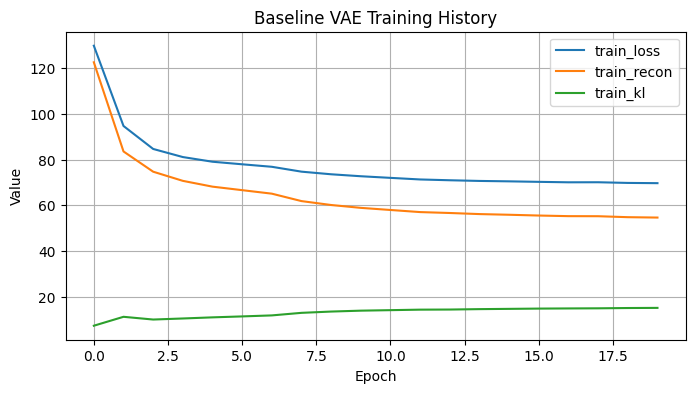

Original images


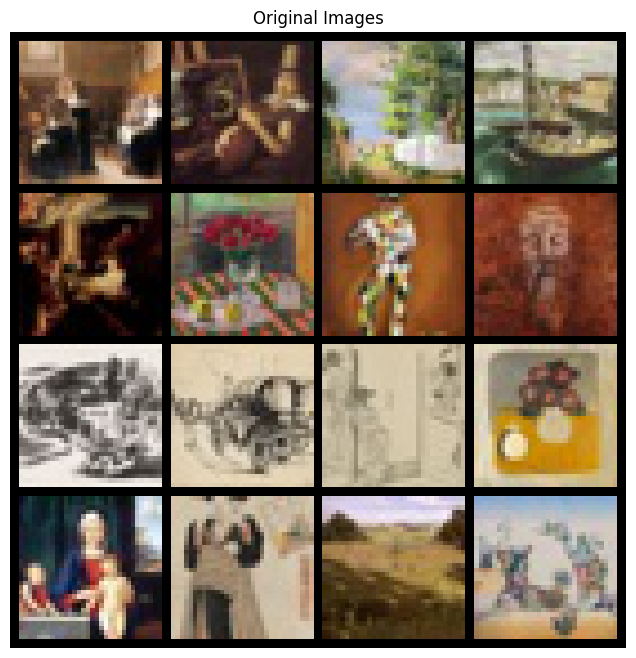

Reconstructed images


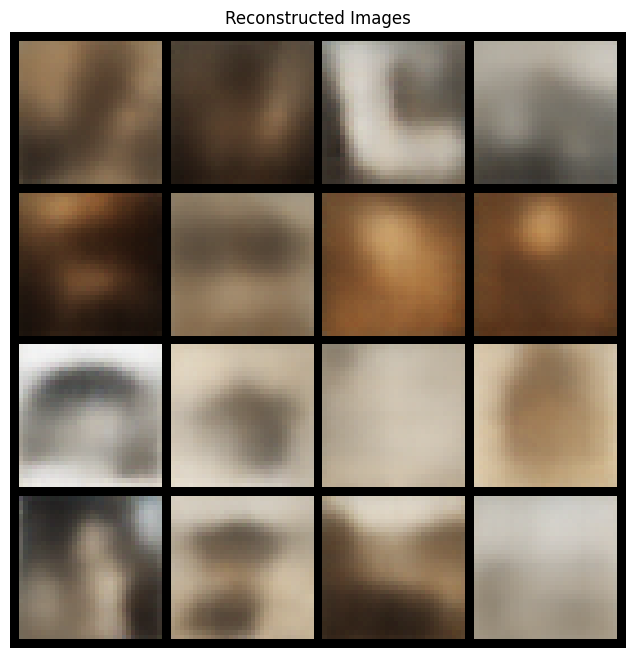

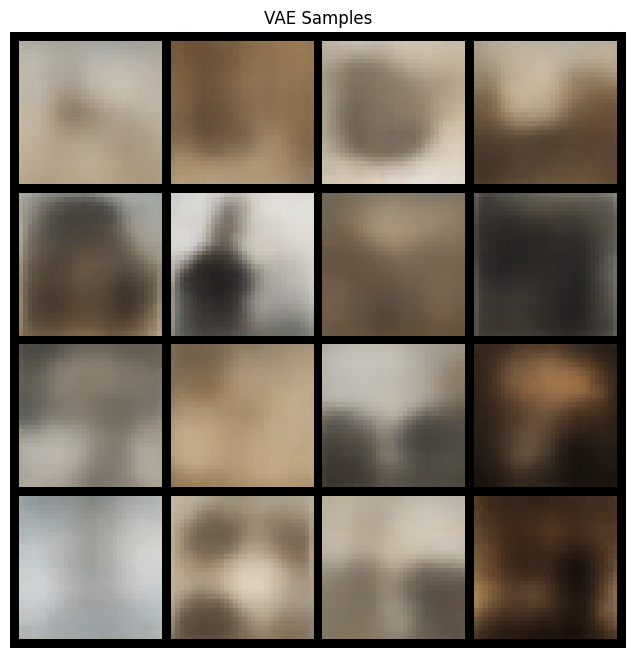

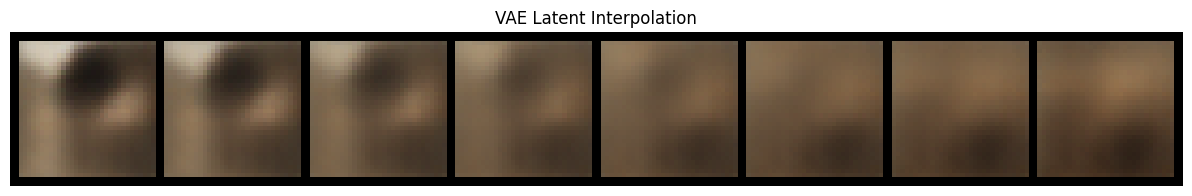

tensor([[[[0.7063, 0.7379, 0.7760,  ..., 0.3374, 0.3266, 0.3303],
          [0.7023, 0.7456, 0.7875,  ..., 0.2920, 0.2945, 0.2952],
          [0.6848, 0.7404, 0.7786,  ..., 0.2824, 0.2759, 0.2826],
          ...,
          [0.4737, 0.5001, 0.5217,  ..., 0.2653, 0.2566, 0.2540],
          [0.4834, 0.5102, 0.5292,  ..., 0.2677, 0.2644, 0.2650],
          [0.4895, 0.5162, 0.5245,  ..., 0.2846, 0.2776, 0.2940]],

         [[0.6857, 0.7065, 0.7493,  ..., 0.2729, 0.2738, 0.2912],
          [0.6734, 0.7124, 0.7560,  ..., 0.2350, 0.2479, 0.2395],
          [0.6517, 0.6923, 0.7398,  ..., 0.2136, 0.2205, 0.2319],
          ...,
          [0.4067, 0.4219, 0.4441,  ..., 0.2137, 0.2127, 0.2223],
          [0.4154, 0.4303, 0.4489,  ..., 0.2211, 0.2120, 0.2170],
          [0.4315, 0.4459, 0.4509,  ..., 0.2297, 0.2321, 0.2488]],

         [[0.6232, 0.6584, 0.6788,  ..., 0.2272, 0.2180, 0.2351],
          [0.6082, 0.6472, 0.6963,  ..., 0.1964, 0.1839, 0.1990],
          [0.5844, 0.6265, 0.6721,  ..., 0

In [16]:
plot_training_history(history, title="Baseline VAE Training History")
show_vae_reconstructions(vae, train_loader_from_csv, device, num_images=16)
sample_vae(vae, device, num_samples=16)
interpolate_vae(vae, train_loader_from_csv, device, num_steps=8)

### VAE Experiment Configurations

In [17]:
# Small hyperparameter search on the official 20% training subset

vae_configs = [
    {"latent_dim": 64,  "beta": 0.5, "learning_rate": 1e-3},
    {"latent_dim": 64,  "beta": 1.0, "learning_rate": 1e-3},
    {"latent_dim": 64,  "beta": 2.0, "learning_rate": 1e-3},
    {"latent_dim": 128, "beta": 0.5, "learning_rate": 1e-3},
    {"latent_dim": 128, "beta": 1.0, "learning_rate": 1e-3},
    {"latent_dim": 128, "beta": 2.0, "learning_rate": 1e-3},
    {"latent_dim": 64,  "beta": 1.0, "learning_rate": 5e-4},
    {"latent_dim": 128, "beta": 1.0, "learning_rate": 5e-4},
]

vae_num_epochs_search = 10

print(f"Number of VAE configurations: {len(vae_configs)}")
for i, config in enumerate(vae_configs, start=1):
    print(f"{i:2d}. {config}")

Number of VAE configurations: 8
 1. {'latent_dim': 64, 'beta': 0.5, 'learning_rate': 0.001}
 2. {'latent_dim': 64, 'beta': 1.0, 'learning_rate': 0.001}
 3. {'latent_dim': 64, 'beta': 2.0, 'learning_rate': 0.001}
 4. {'latent_dim': 128, 'beta': 0.5, 'learning_rate': 0.001}
 5. {'latent_dim': 128, 'beta': 1.0, 'learning_rate': 0.001}
 6. {'latent_dim': 128, 'beta': 2.0, 'learning_rate': 0.001}
 7. {'latent_dim': 64, 'beta': 1.0, 'learning_rate': 0.0005}
 8. {'latent_dim': 128, 'beta': 1.0, 'learning_rate': 0.0005}


## VAE Experiment Runner

In [18]:
def run_vae_experiment(config, train_loader, device, num_epochs=10, seed=42):
    """
    Train one VAE configuration and return:
    - the trained model
    - the training history
    - a result summary dictionary
    """
    set_seed(seed)

    latent_dim = config["latent_dim"]
    beta = config["beta"]
    learning_rate = config["learning_rate"]

    model = ConvVAE(latent_dim=latent_dim).to(device)
    optimiser = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_recon": [],
        "train_kl": [],
    }

    print("-" * 70)
    print(
        f"Training VAE | latent_dim={latent_dim} | "
        f"beta={beta} | learning_rate={learning_rate}"
    )
    print(f"Trainable parameters: {count_parameters(model):,}")

    for epoch in range(num_epochs):
        train_loss, train_recon, train_kl = train_one_epoch_vae(
            model=model,
            dataloader=train_loader,
            optimizer=optimiser,
            device=device,
            beta=beta,
        )

        history["train_loss"].append(train_loss)
        history["train_recon"].append(train_recon)
        history["train_kl"].append(train_kl)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"loss={train_loss:.4f} "
            f"recon={train_recon:.4f} "
            f"kl={train_kl:.4f}"
        )

    result = {
        "latent_dim": latent_dim,
        "beta": beta,
        "learning_rate": learning_rate,
        "num_epochs": num_epochs,
        "final_train_loss": history["train_loss"][-1],
        "final_train_recon": history["train_recon"][-1],
        "final_train_kl": history["train_kl"][-1],
    }

    return model, history, result

## Run VAE Experiments

In [19]:
vae_models = []
vae_histories = []
vae_results = []

for run_idx, config in enumerate(vae_configs, start=1):
    print(f"\nStarting VAE experiment {run_idx}/{len(vae_configs)}")

    model, history, result = run_vae_experiment(
        config=config,
        train_loader=train_loader_from_csv,
        device=device,
        num_epochs=vae_num_epochs_search,
        seed=SEED,
    )

    result["run_idx"] = run_idx

    vae_models.append(model)
    vae_histories.append(history)
    vae_results.append(result)


Starting VAE experiment 1/8
----------------------------------------------------------------------
Training VAE | latent_dim=64 | beta=0.5 | learning_rate=0.001
Trainable parameters: 1,711,939


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [1/10] loss=126.2521 recon=121.0799 kl=10.3444


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [2/10] loss=80.6996 recon=73.3220 kl=14.7552


...

Epoch [8/10] loss=74.3717 recon=61.5059 kl=12.8658


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [9/10] loss=73.8039 recon=60.6296 kl=13.1743


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [10/10] loss=73.2038 recon=59.7666 kl=13.4372


## VAE Results Table

In [20]:
import pandas as pd

vae_results_df = pd.DataFrame(vae_results)
vae_results_df = vae_results_df.sort_values(
    by="final_train_loss",
    ascending=True
).reset_index(drop=True)

vae_results_df

,latent_dim,beta,learning_rate,num_epochs,final_train_loss,final_train_recon,final_train_kl,run_idx
0,64,0.5,0.0010,10,60.589876,49.732542,21.714670,1
1,128,0.5,0.0010,10,61.682207,50.608702,22.147010,4
2,64,1.0,0.0010,10,71.187570,56.985969,14.201601,2
3,64,1.0,0.0005,10,71.471545,57.803672,13.667873,7
4,128,1.0,0.0010,10,72.741462,58.905023,13.836439,5
5,128,1.0,0.0005,10,73.203768,59.766605,13.437163,8
6,64,2.0,0.0010,10,86.168554,70.962434,7.603060,3
7,128,2.0,0.0010,10,87.175187,72.336079,7.419554,6


## Best VAE From Search

In [21]:
best_vae_row = vae_results_df.iloc[0]
best_vae_run_idx = int(best_vae_row["run_idx"]) - 1

best_vae_model = vae_models[best_vae_run_idx]
best_vae_history = vae_histories[best_vae_run_idx]

print("Best VAE configuration:")
print(best_vae_row)

Best VAE configuration:
latent_dim           64.000000
beta                  0.500000
learning_rate         0.001000
num_epochs           10.000000
final_train_loss     60.589876
final_train_recon    49.732542
final_train_kl       21.714670
run_idx               1.000000
Name: 0, dtype: float64


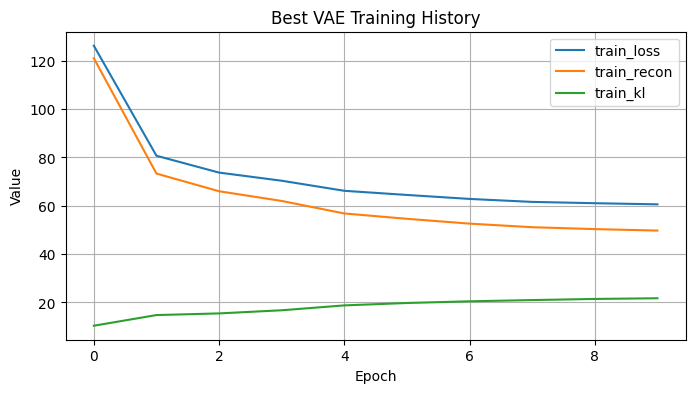

Original images


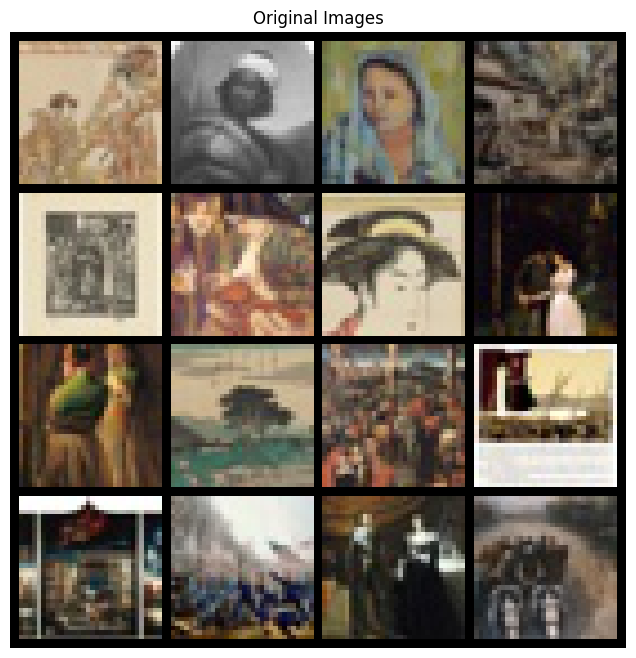

Reconstructed images


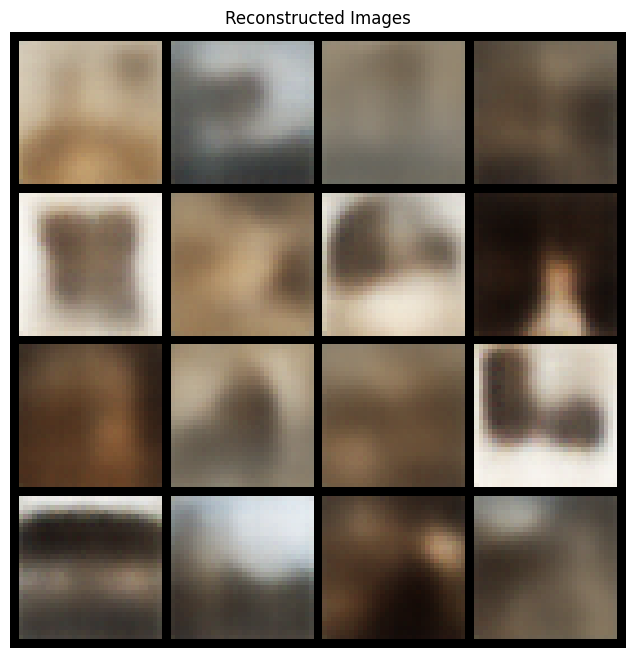

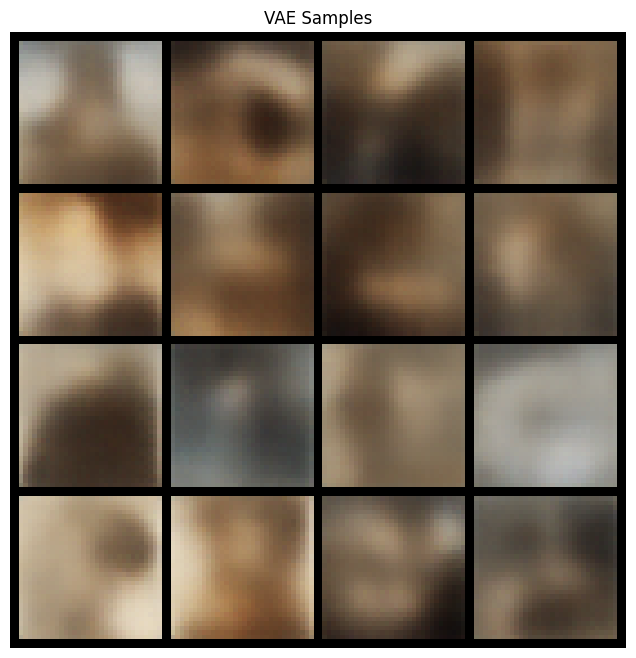

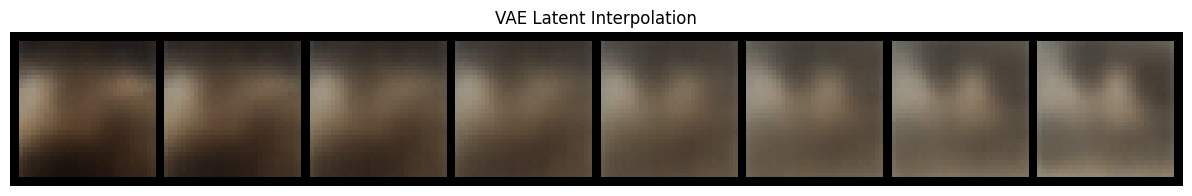

tensor([[[[0.1828, 0.1619, 0.1617,  ..., 0.1337, 0.1479, 0.1823],
          [0.1754, 0.1511, 0.1514,  ..., 0.1310, 0.1474, 0.1708],
          [0.1832, 0.1829, 0.1694,  ..., 0.1471, 0.1572, 0.1637],
          ...,
          [0.2325, 0.2309, 0.1893,  ..., 0.2234, 0.2472, 0.2504],
          [0.2248, 0.1974, 0.1826,  ..., 0.2118, 0.2331, 0.2537],
          [0.2288, 0.1900, 0.1656,  ..., 0.2129, 0.2306, 0.2546]],

         [[0.1678, 0.1258, 0.1328,  ..., 0.1201, 0.1353, 0.1583],
          [0.1669, 0.1418, 0.1316,  ..., 0.1197, 0.1407, 0.1487],
          [0.1734, 0.1572, 0.1705,  ..., 0.1226, 0.1448, 0.1478],
          ...,
          [0.1887, 0.1530, 0.1455,  ..., 0.1639, 0.1729, 0.2001],
          [0.1682, 0.1441, 0.1283,  ..., 0.1509, 0.1675, 0.1899],
          [0.1876, 0.1450, 0.1259,  ..., 0.1501, 0.1652, 0.1936]],

         [[0.1390, 0.1439, 0.1184,  ..., 0.1107, 0.1283, 0.1315],
          [0.1490, 0.1361, 0.1385,  ..., 0.1096, 0.1233, 0.1409],
          [0.1714, 0.1574, 0.1421,  ..., 0

In [22]:
plot_training_history(best_vae_history, title="Best VAE Training History")

show_vae_reconstructions(
    best_vae_model,
    train_loader_from_csv,
    device,
    num_images=16,
)

sample_vae(
    best_vae_model,
    device,
    num_samples=16,
)

interpolate_vae(
    best_vae_model,
    train_loader_from_csv,
    device,
    num_steps=8,
)

## Save Best VAE Checkpoint

In [23]:
best_checkpoint_path = "checkpoints/vae/best_vae_from_search.pt"

save_checkpoint(
    model=best_vae_model,
    optimizer=None,
    epoch=int(best_vae_row["num_epochs"]),
    path=best_checkpoint_path,
    history=best_vae_history,
    extra={
        "latent_dim": int(best_vae_row["latent_dim"]),
        "beta": float(best_vae_row["beta"]),
        "learning_rate": float(best_vae_row["learning_rate"]),
        "selection_metric": "final_train_loss",
    },
)

Checkpoint saved to: checkpoints\vae\best_vae_from_search.pt
